In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# x=np.array([95,85,80,70,60])
# y=np.array([85,95,70,65,70])
x = np.array([1, 2, 3])
y = np.array([2, 4, 6])

In [3]:
model= np.polyfit(x, y, 1)
# np.polyfit():
# - Finds the best-fit polynomial
# - Uses least squares method
# - Minimizes the sum of squared errors
# For degree = 1, it finds:   y=mx+b
# What is stored in model?
#     model = [m, b]
# m → slope (weight)
# b → intercept (bias)
model

array([2.0000000e+00, 2.0511602e-15])

In [4]:
# 1. 
m, b = model
y_val = m * 5 + b
print(y_val)

# 2. 
line = np.poly1d(model)
y_val = line(5)
print(y_val)

predict = np.poly1d(model)
predict(10)
predict(5)

9.999999999999998
9.999999999999998


np.float64(9.999999999999998)

In [5]:
# Predict the y_pred for all values of x.
y_pred=predict(x)
y_pred
# from sklearn.metrics import r2_score
type(y_pred)
r2_score(y, y_pred)

1.0

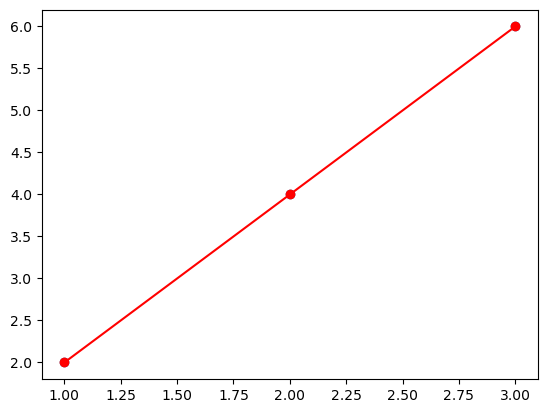

In [6]:
y_line = model[1] + model[0]* x
plt.plot(x, y_line, c = 'r')
plt.scatter(x, y_pred)
plt.scatter(x,y,c='r')

In [7]:
data = pd.read_csv("BostonHousing.csv")
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [8]:
print(data.isnull().sum())
data = data.fillna(data.mean())

crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


In [9]:
X = data.drop(['medv'], axis=1)
y = data['medv']

In [10]:
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=0)

In [11]:
# import sklearn
# from sklearn.linear_model import LinearRegression
lm = LinearRegression()
model=lm.fit(xtrain, ytrain)

In [12]:
ytrain_pred = lm.predict(xtrain)
ytest_pred = lm.predict(xtest)

In [13]:
df=pd.DataFrame(ytrain_pred,ytrain)
df=pd.DataFrame(ytest_pred,ytest)

In [14]:
# from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(ytest, ytest_pred)
print(mse)
mse = mean_squared_error(ytrain_pred,ytrain)
print(mse)

33.4649759889145
19.391606535694894


In [15]:
mse = mean_squared_error(ytest, ytest_pred)
print(mse)

33.4649759889145


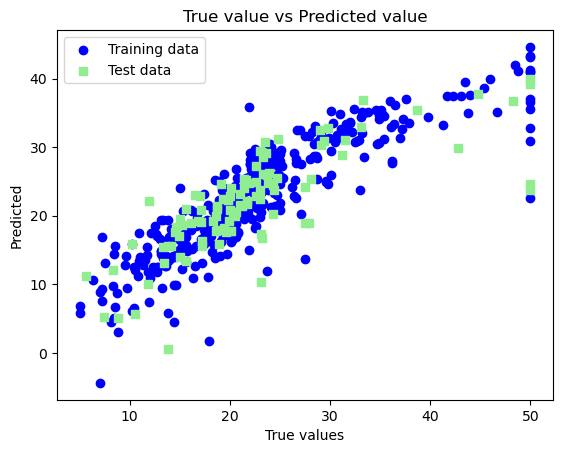

In [16]:
plt.scatter(ytrain ,ytrain_pred,c='blue',marker='o',label='Training data')
plt.scatter(ytest,ytest_pred ,c='lightgreen',marker='s',label='Test data')
plt.xlabel('True values')
plt.ylabel('Predicted')
plt.title("True value vs Predicted value")
plt.legend(loc= 'upper left')
#plt.hlines(y=0,xmin=0,xmax=50)
plt.plot()
plt.show()